In [64]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

In [65]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

In [66]:
# 1. LES DATA
# --------------------------------------------------
print("Leser data ...")
train = pd.read_csv("https://raw.githubusercontent.com/jensmorten/sykkelprofet/refs/heads/main/konkurranse/bysykkel_train.csv", parse_dates=["ds"])
test = pd.read_csv("https://raw.githubusercontent.com/jensmorten/sykkelprofet/refs/heads/main/konkurranse/test_compete.csv", parse_dates=["ds"])
test_truth=pd.read_csv("test_target_secret.csv", parse_dates=["ds"])
train = train.sort_values("ds")
test = test.sort_values("ds")
test_truth=test_truth.sort_values("ds")
print("done!")

Leser data ...
done!


In [67]:
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)


In [68]:
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train[["y"]])

window = 56 

X_train, y_train = create_sequences(scaled_train, window)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

In [69]:
model_lstm = Sequential([
    #LSTM(100, activation='tanh',return_sequences=True, input_shape=(window, 1)),
    #LSTM(75, activation='tanh',return_sequences=True, input_shape=(window, 1)),
    #LSTM(50, activation='tanh',return_sequences=True, input_shape=(window, 1)),
    LSTM(10, activation='tanh'), 
    Dense(1)
])

model_lstm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05), loss='mse')

model_lstm.fit(X_train, y_train, epochs=10, batch_size=112, verbose=1)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0082
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0037
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0023
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0021
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0022
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0019
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018
Epoch 9/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0019
Epoch 10/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0018


In [70]:
history = scaled_train[-window:].flatten().tolist()
predictions = []

for _ in range(len(test)):
    x_input = np.array(history[-window:]).reshape((1, window, 1))
    yhat = model_lstm.predict(x_input, verbose=0)
    predictions.append(yhat[0,0])
    history.append(yhat[0,0])

# Skaler tilbake
lstm_pred = scaler.inverse_transform(np.array(predictions).reshape(-1,1)).flatten()

rmse_lstm = mean_squared_error(test_truth["y"].values, lstm_pred)

print("LSTM RMSE:", rmse_lstm)

LSTM RMSE: 18539.097380691397


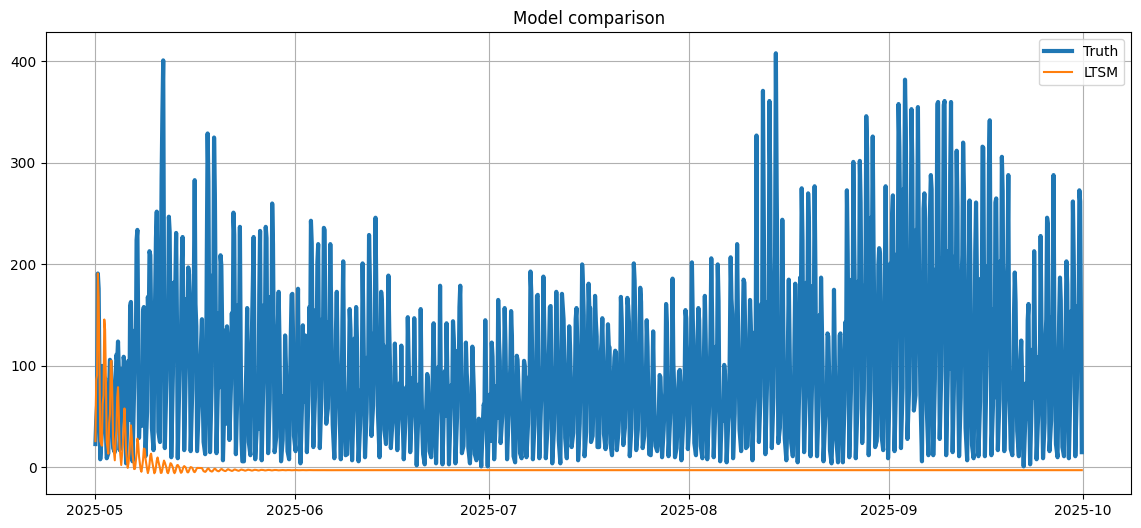

In [71]:
plt.figure(figsize=(14,6))

plt.plot(test["ds"], test_truth["y"], label="Truth", linewidth=3)
plt.plot(test["ds"], lstm_pred, label="LTSM")

plt.title("Model comparison")
plt.legend()
plt.grid(True)
plt.show()